In [1]:
! pip install colorspacious

In [2]:
# Import Libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import math
from colorspacious import cspace_converter
import calendar
import matplotlib.ticker as mtick

## EDA

In [3]:
df = pd.read_csv(r"C:\Users\abhis\Downloads\electricity_2024_2025_combined.csv")

## Basic Info  of the data 
print("Dataset shape",df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing Values")
print(df.isnull().sum())
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Dataset shape (17544, 22)

Column names:
['Datetime (UTC)', 'Country', 'Zone name', 'Zone id', 'Carbon intensity gCO2eq/kWh (direct)', 'Carbon intensity gCO2eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'nuclear', 'geothermal', 'biomass', 'coal', 'wind', 'solar', 'hydro', 'gas', 'oil', 'unknown', 'hydro discharge', 'battery discharge', 'Fossil only CI gCO2eq/kWh', 'Total Load MW']

Data types:
Datetime (UTC)                               object
Country                                      object
Zone name                                    object
Zone id                                      object
Carbon intensity gCO2eq/kWh (direct)        float64
Carbon intensity gCO2eq/kWh (Life cycle)    float64
Carbon-free energy percentage (CFE%)        float64
Renewable energy percentage (RE%)           float64
nuclear                                       int64
geothermal                                    int64
biomass                       

### Data Pre Processing


In [4]:
# Feature Engineering

df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'], errors='coerce')

# Basic time features
df['Year'] = df['Datetime (UTC)'].dt.year
df['Month'] = df['Datetime (UTC)'].dt.month
df['Day'] = df['Datetime (UTC)'].dt.day
df['Hour'] = df['Datetime (UTC)'].dt.hour
df['DayOfWeek'] = df['Datetime (UTC)'].dt.dayofweek
df['WeekOfYear'] = df['Datetime (UTC)'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Datetime (UTC)'].dt.quarter
df['Month_Name'] = df['Month'].apply(lambda x: calendar.month_abbr[x])


# Season feature
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Summer', 5: 'Summer',
    6: 'Summer', 7: 'Rain', 8: 'Rain', 9: 'Rain',
    10: 'Autumn', 11: 'Winter'
})


# TimeOfDay feature
conditions = [
    (df['Hour'] >= 5) & (df['Hour'] < 12),
    (df['Hour'] >= 12) & (df['Hour'] < 15),
    (df['Hour'] >= 15) & (df['Hour'] < 17),
    (df['Hour'] >= 17) & (df['Hour'] < 21),
    (df['Hour'] >= 21) | (df['Hour'] < 5)
]

choices = [
    'Morning',
    'Early Afternoon',
    'Late Afternoon',
    'Evening',
    'Night'
]

df['TimeOfDay'] = np.select(conditions, choices,default='Unknown')


# Carbon Emission (Tonne)

df['Carbon Emission (tonne)'] = (
    df['Total Load MW'] *
    df['Carbon intensity gCO2eq/kWh (direct)'] *
    0.001
)


In [5]:

# All columns with numerical values 
numeric_cols = ['Carbon intensity gCO2eq/kWh (direct)','Carbon intensity gCO2eq/kWh (Life cycle)','Carbon-free energy percentage (CFE%)','Renewable energy percentage (RE%)','nuclear','geothermal','biomass','coal','wind','solar','hydro','gas','oil','unknown','hydro discharge','battery discharge',
'Fossil only CI gCO2eq/kWh','Total Load MW']


# Checking for outliers using Inter Quartile range 
def detect_outliers(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1 
    low_bound = Q1 - 1.5 *IQR
    upper_bound = Q1 + 1.5 *IQR
    outliers = df[(df[column]< low_bound)|(df[column]>upper_bound)]
    return outliers,low_bound,upper_bound

# To check outliers for each  numerical column 
for col in numeric_cols :
    outliers,lower,upper = detect_outliers(df,col)
    print(f"\n{col}") 
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"Range: {lower:.2f} to {upper:.2f}")


Carbon intensity gCO2eq/kWh (direct)
Outliers: 100 (0.57%)
Range: 356.28 to 666.66

Carbon intensity gCO2eq/kWh (Life cycle)
Outliers: 116 (0.66%)
Range: 402.24 to 723.27

Carbon-free energy percentage (CFE%)
Outliers: 1830 (10.43%)
Range: -2.29 to 38.79

Renewable energy percentage (RE%)
Outliers: 1818 (10.36%)
Range: -6.08 to 35.98

nuclear
Outliers: 1086 (6.19%)
Range: 4022.00 to 7100.00

geothermal
Outliers: 0 (0.00%)
Range: 0.00 to 0.00

biomass
Outliers: 0 (0.00%)
Range: 0.00 to 0.00

coal
Outliers: 959 (5.47%)
Range: 94713.38 to 175630.12

wind
Outliers: 2271 (12.94%)
Range: -5766.00 to 20775.00

solar
Outliers: 1978 (11.27%)
Range: -46916.38 to 47146.38

hydro
Outliers: 705 (4.02%)
Range: -14867.25 to 35024.25

gas
Outliers: 2709 (15.44%)
Range: -255.50 to 4763.50

oil
Outliers: 87 (0.50%)
Range: -9.00 to 9.00

unknown
Outliers: 3312 (18.88%)
Range: -852.00 to 2904.00

hydro discharge
Outliers: 0 (0.00%)
Range: 0.00 to 0.00

battery discharge
Outliers: 0 (0.00%)
Range: 0.00 to

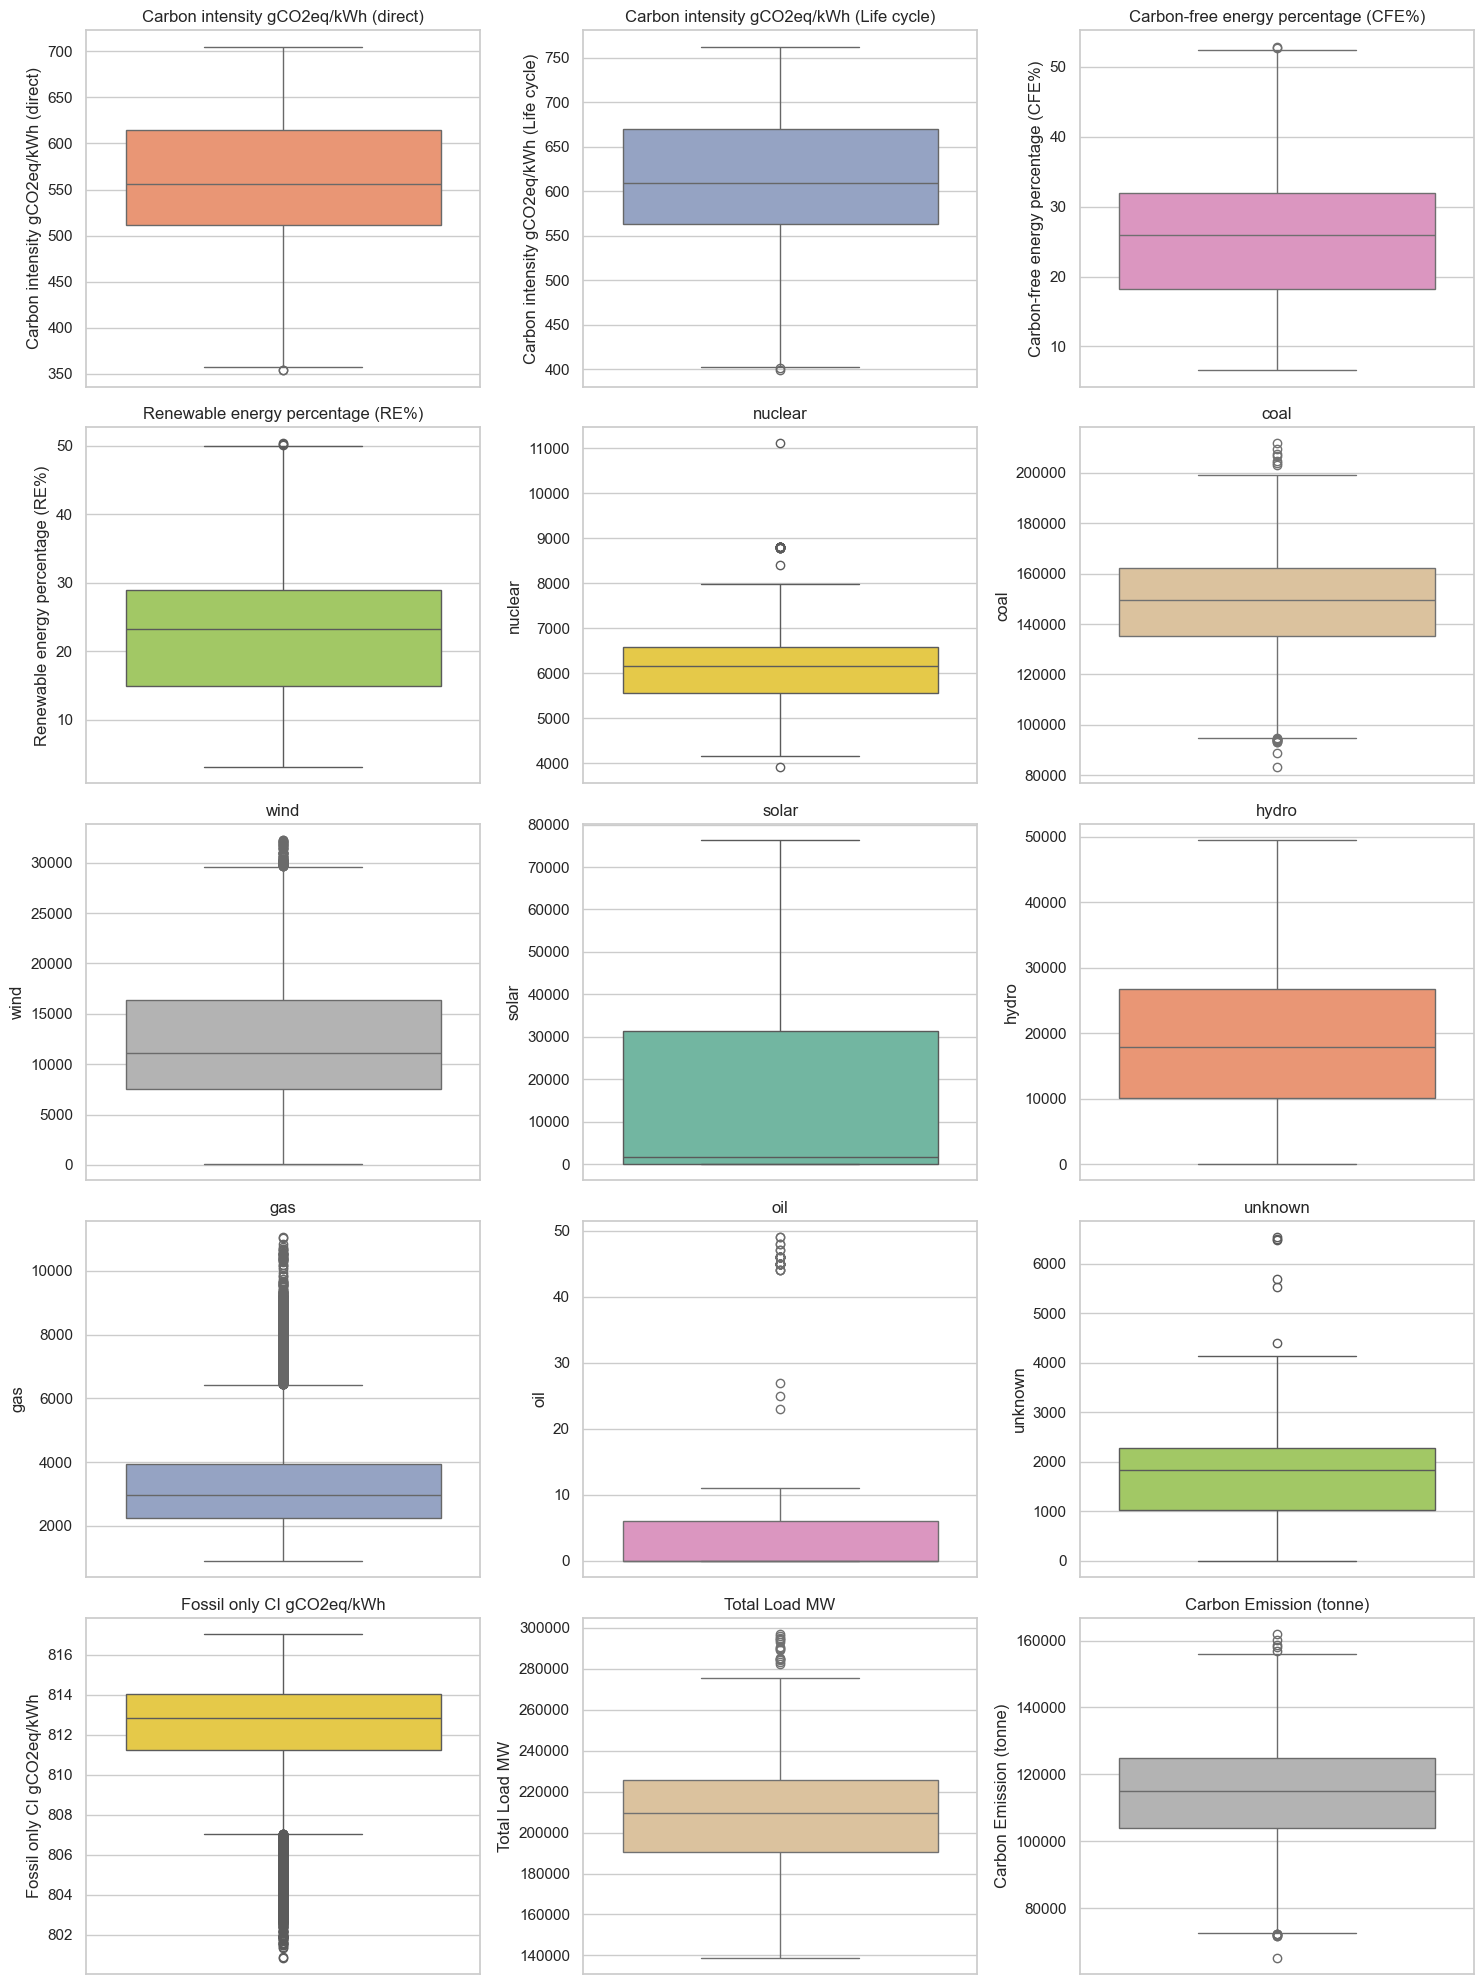

In [6]:
# Box Plot of numerical features


numeric_cols= [
    'Carbon intensity gCO2eq/kWh (direct)',
    'Carbon intensity gCO2eq/kWh (Life cycle)',
    'Carbon-free energy percentage (CFE%)',
    'Renewable energy percentage (RE%)',
    'nuclear','coal','wind','solar','hydro',
    'gas','oil','unknown',
    'Fossil only CI gCO2eq/kWh','Total Load MW','Carbon Emission (tonne)'
]

# Set colorful theme
sns.set(style="whitegrid", palette="Set2")

# Grid size
cols = 3
rows = math.ceil(len(numeric_cols) / cols)

# Create figure
plt.figure(figsize=(15, rows * 4))

# Loop with colors
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    
    sns.boxplot(
        y=df[col],
        color=sns.color_palette("Set2")[i % len(sns.color_palette("Set2"))]
    )
    
    plt.title(col, fontsize=12)
    plt.xlabel("")

# Layout
plt.tight_layout()
plt.show()

In [7]:

#  Min/Max Values for Features

key_features = ['Carbon intensity gCO2eq/kWh (direct)','Carbon intensity gCO2eq/kWh (Life cycle)','Carbon-free energy percentage (CFE%)','Renewable energy percentage (RE%)','nuclear','geothermal','biomass','coal','wind','solar','hydro','gas','oil','unknown','hydro discharge','battery discharge',
'Fossil only CI gCO2eq/kWh','Total Load MW']

df_selected = df[key_features]

# Get min and max
min_max_df = pd.DataFrame({
    'Feature': df_selected.columns,
    'Min Value': df_selected.min(),
    'Max Value': df_selected.max()
})

# Reset index for clean view
min_max_df = min_max_df.reset_index(drop=True)

print(min_max_df)

                                     Feature  Min Value  Max Value
0       Carbon intensity gCO2eq/kWh (direct)     353.73     705.21
1   Carbon intensity gCO2eq/kWh (Life cycle)     398.68     762.81
2       Carbon-free energy percentage (CFE%)       6.58      52.89
3          Renewable energy percentage (RE%)       3.05      50.31
4                                    nuclear    3918.00   11103.00
5                                 geothermal       0.00       0.00
6                                    biomass       0.00       0.00
7                                       coal   83203.00  211622.00
8                                       wind      89.00   32214.00
9                                      solar       0.00   76296.00
10                                     hydro       0.00   49419.00
11                                       gas     899.00   11058.00
12                                       oil       0.00      49.00
13                                   unknown       0.00    653

In [8]:
# Detailed Statistical Summary 

# Select numeric features

# Generate detailed summary
summary_stats = df_selected.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T

# Rename columns for clarity
summary_stats = summary_stats.rename(columns={
    'mean': 'Mean',
    'std': 'Std Dev',
    '1%': '1%',
    '25%': '25%',
    '50%': 'Median',
    '75%': '75%',
    '99%': '99%',
    'max': 'Max'
})

print(summary_stats)

                                            count           Mean  \
Carbon intensity gCO2eq/kWh (direct)      17544.0     554.935790   
Carbon intensity gCO2eq/kWh (Life cycle)  17544.0     607.913760   
Carbon-free energy percentage (CFE%)      17544.0      26.130269   
Renewable energy percentage (RE%)         17544.0      23.154426   
nuclear                                   17544.0    6071.608755   
geothermal                                17544.0       0.000000   
biomass                                   17544.0       0.000000   
coal                                      17544.0  148308.090116   
wind                                      17544.0   12255.260773   
solar                                     17544.0   16454.937756   
hydro                                     17544.0   18903.642157   
gas                                       17544.0    3403.235807   
oil                                       17544.0       2.888509   
unknown                                   17544.

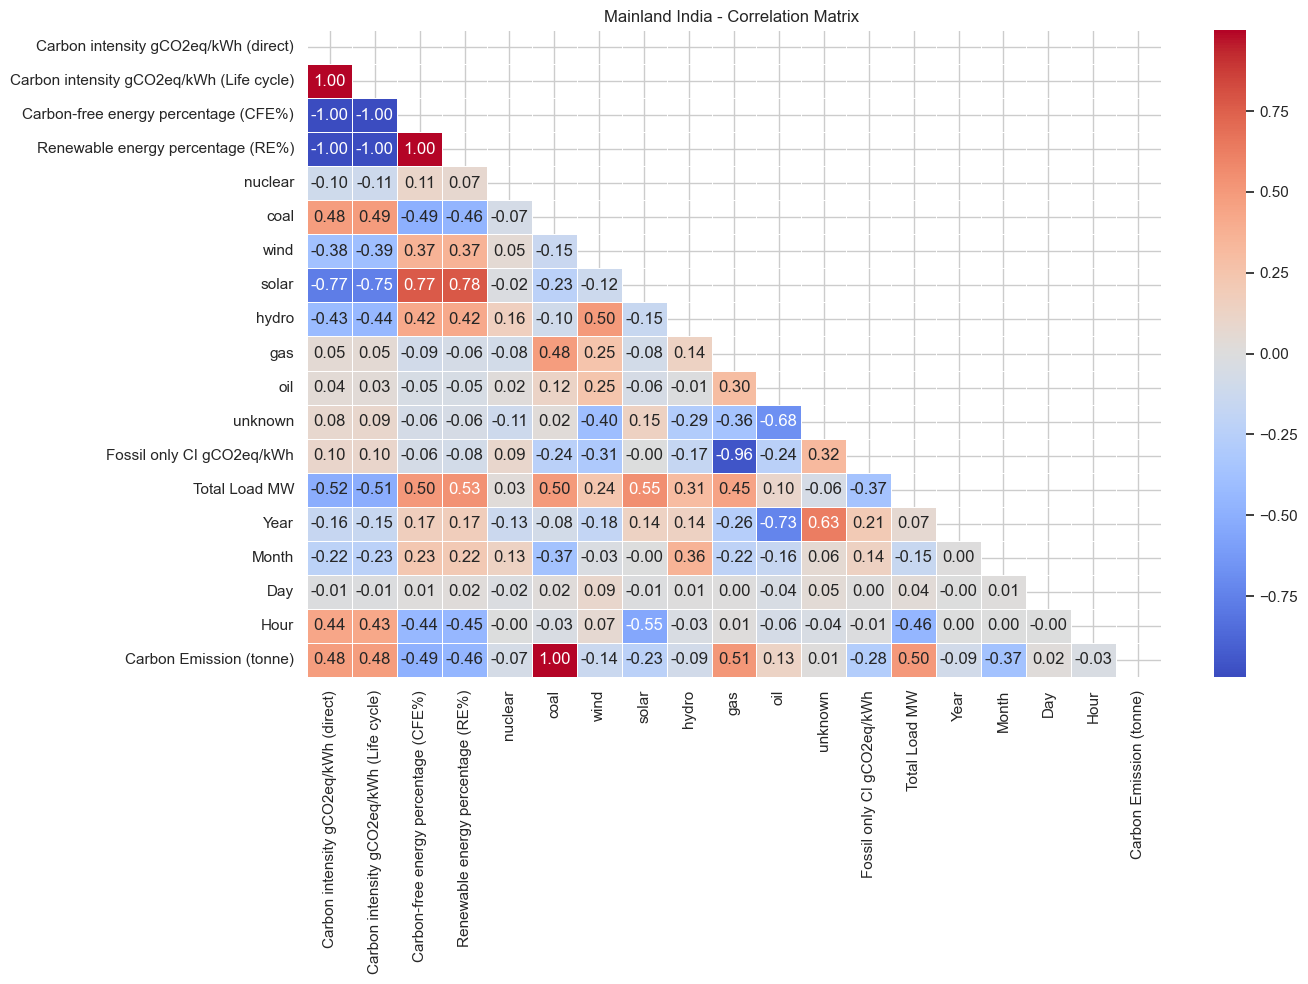

In [9]:
# Correlation Matrix


numeric_cols101 = [
    'Carbon intensity gCO2eq/kWh (direct)',
    'Carbon intensity gCO2eq/kWh (Life cycle)',
    'Carbon-free energy percentage (CFE%)',
    'Renewable energy percentage (RE%)',
    'nuclear','coal','wind','solar','hydro',
    'gas','oil','unknown',
    'Fossil only CI gCO2eq/kWh','Total Load MW','Year','Month','Day','Hour','Carbon Emission (tonne)'
]


numeric_df1 = df[numeric_cols101]


corr_matrix = numeric_df1.corr()



# Mask upper triangle (clean look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mainland India - Correlation Matrix ")
plt.tight_layout()
plt.show()


In [10]:
# Carbon Intensity (direct) Analysis 

carbon_col = 'Carbon intensity gCO2eq/kWh (direct)'

# Calculate skewness & kurtosis
skew_value = df[carbon_col].skew()
kurt_value = df[carbon_col].kurtosis()

print(f"Skewness: {skew_value}")              
print(f"Kurtosis: {kurt_value}")      # We can see it is left skewed & has fewer outliers ( <0)

Skewness: -0.4632484348691439
Kurtosis: -0.47907361474950916


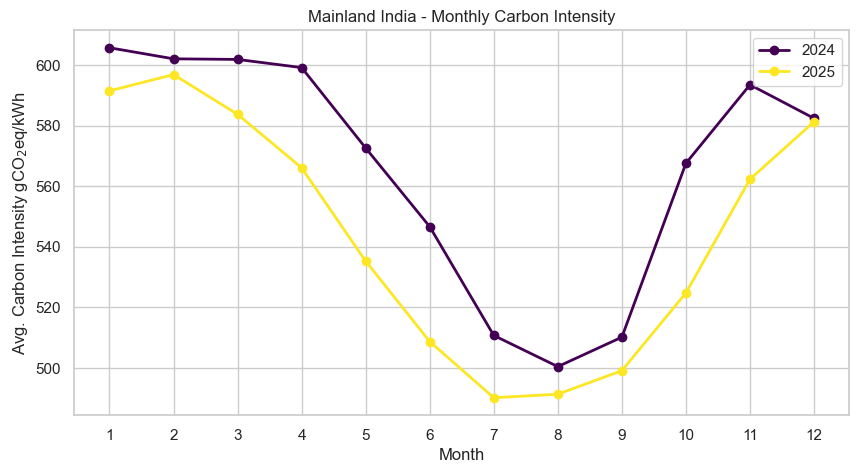

In [29]:
# Monthly Pattern (2024vs 2025)

monthly_mean = df.groupby(['Year', 'Month'])['Carbon intensity gCO2eq/kWh (direct)'].mean().reset_index()


cmap = plt.get_cmap('viridis')

plt.figure(figsize=(10,5))

years = sorted(monthly_mean['Year'].unique())

for i, year in enumerate(years):
    subset = monthly_mean[monthly_mean['Year'] == year]
    
    plt.plot(subset['Month'],
             subset['Carbon intensity gCO2eq/kWh (direct)'],
             color=cmap(i / (len(years)-1)),  # smooth gradient
             marker='o',
             linewidth=2,
             label=f"{year}")

plt.title("Mainland India - Monthly Carbon Intensity")
plt.xlabel("Month")
plt.ylabel("Avg. Carbon Intensity gCO$_2$eq/kWh")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

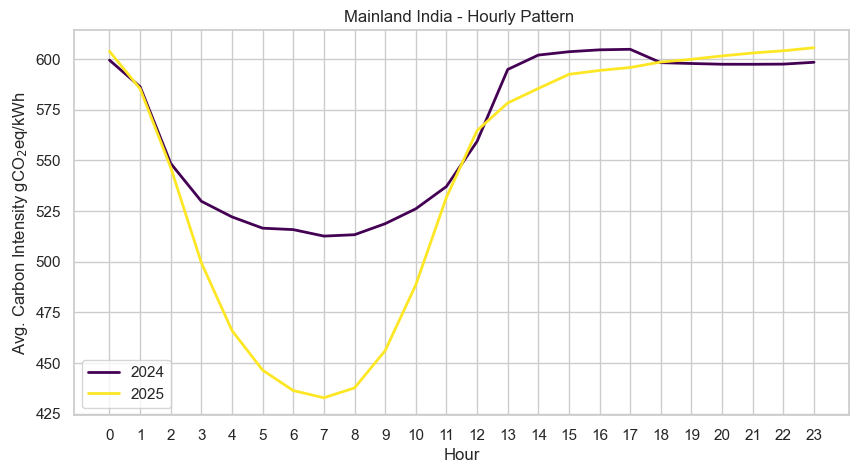

In [30]:
# Hourly pattern
hourly_mean = df.groupby(['Year', 'Hour'])['Carbon intensity gCO2eq/kWh (direct)'].mean().reset_index()

cmap = plt.get_cmap('viridis')
plt.figure(figsize=(10,5))

for i, year in enumerate(years):
    subset = hourly_mean[hourly_mean['Year'] == year]
    
    plt.plot(subset['Hour'],
             subset['Carbon intensity gCO2eq/kWh (direct)'],
             color=cmap(i / (len(years)-1)),
             linewidth=2,
             label=f"{year}")

plt.title("Mainland India - Hourly Pattern ")
plt.xlabel("Hour")
plt.ylabel("Avg. Carbon Intensity gCO$_2$eq/kWh")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

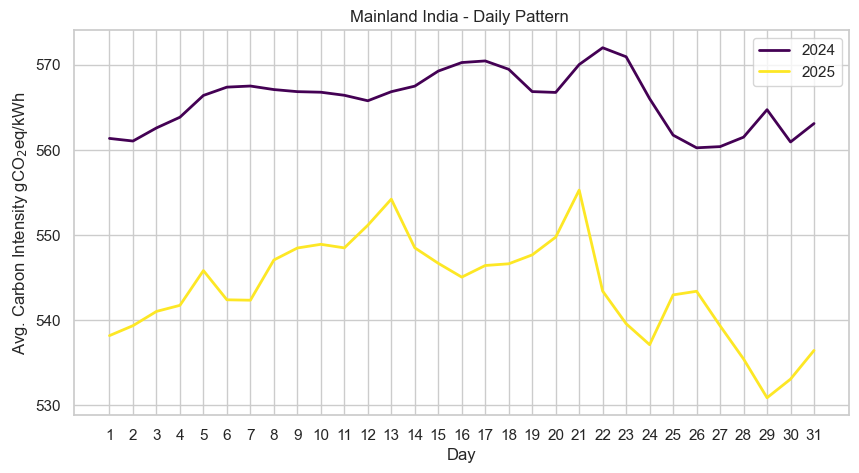

In [31]:
# Daily Pattern (DAy of Month)

daily_mean = df.groupby(['Year', 'Day'])['Carbon intensity gCO2eq/kWh (direct)'].mean().reset_index()

cmap = plt.get_cmap('viridis')
plt.figure(figsize=(10,5))

for i, year in enumerate(years):
    subset = daily_mean[daily_mean['Year'] == year]
    
    plt.plot(subset['Day'],
             subset['Carbon intensity gCO2eq/kWh (direct)'],
             color=cmap(i / (len(years)-1)),
             linewidth=2,
             label=f"{year}")

plt.title("Mainland India - Daily Pattern ")
plt.xlabel("Day")
plt.ylabel("Avg. Carbon Intensity gCO$_2$eq/kWh")
plt.legend()
plt.xticks(range(1, 32))
plt.show()

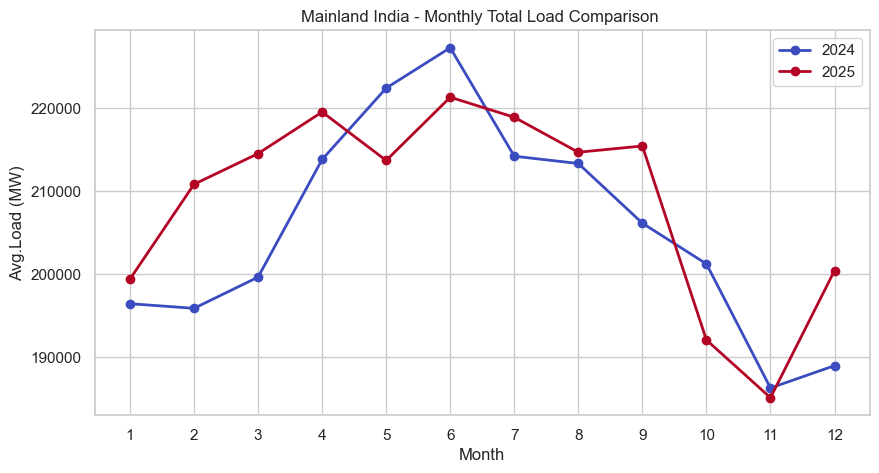

In [32]:
# Month Load Pattern

monthly_load = df.groupby(['Year', 'Month'])['Total Load MW'].mean().reset_index()

cmap = plt.get_cmap('coolwarm')

plt.figure(figsize=(10,5))

years = sorted(monthly_load['Year'].unique())

for i, year in enumerate(years):
    subset = monthly_load[monthly_load['Year'] == year]
    
    plt.plot(subset['Month'],
             subset['Total Load MW'],
             color=cmap(i / (len(years)-1)),
             marker='o',
             linewidth=2,
             label=f"{year}")

plt.title("Mainland India - Monthly Total Load Comparison ")
plt.xlabel("Month")
plt.ylabel("Avg.Load (MW)")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

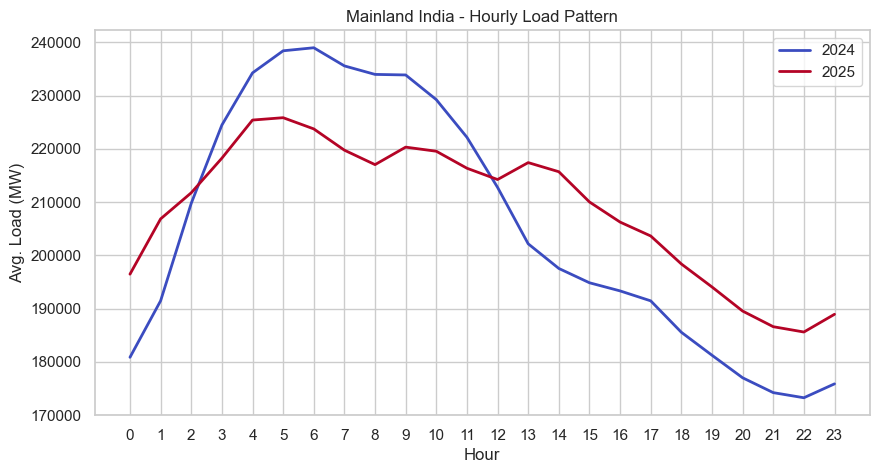

In [34]:
# Hourly Load Pattern
hourly_load = df.groupby(['Year', 'Hour'])['Total Load MW'].mean().reset_index()

cmap = plt.get_cmap('coolwarm')
plt.figure(figsize=(10,5))

for i, year in enumerate(years):
    subset = hourly_load[hourly_load['Year'] == year]
    
    plt.plot(subset['Hour'],
             subset['Total Load MW'],
             color=cmap(i / (len(years)-1)),
             linewidth=2,
             label=f"{year}")

plt.title("Mainland India - Hourly Load Pattern")
plt.xlabel("Hour")
plt.ylabel("Avg. Load (MW)")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

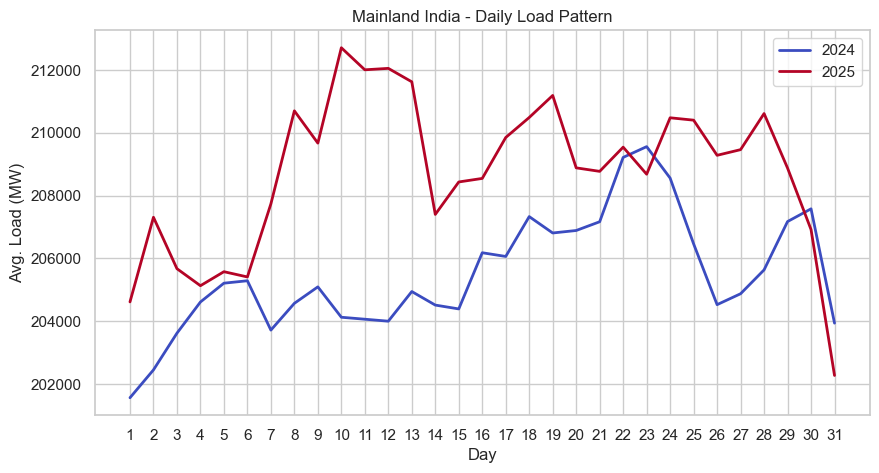

In [36]:
# Daily Load Pattern

daily_load = df.groupby(['Year', 'Day'])['Total Load MW'].mean().reset_index()

cmap = plt.get_cmap('coolwarm')
plt.figure(figsize=(10,5))

for i, year in enumerate(years):
    subset = daily_load[daily_load['Year'] == year]
    
    plt.plot(subset['Day'],
             subset['Total Load MW'],
             color=cmap(i / (len(years)-1)),
             linewidth=2,
             label=f"{year}")

plt.title("Mainland India - Daily Load Pattern")
plt.xlabel("Day")
plt.ylabel("Avg. Load (MW)")
plt.xticks(range(1, 32))
plt.legend()
plt.show()

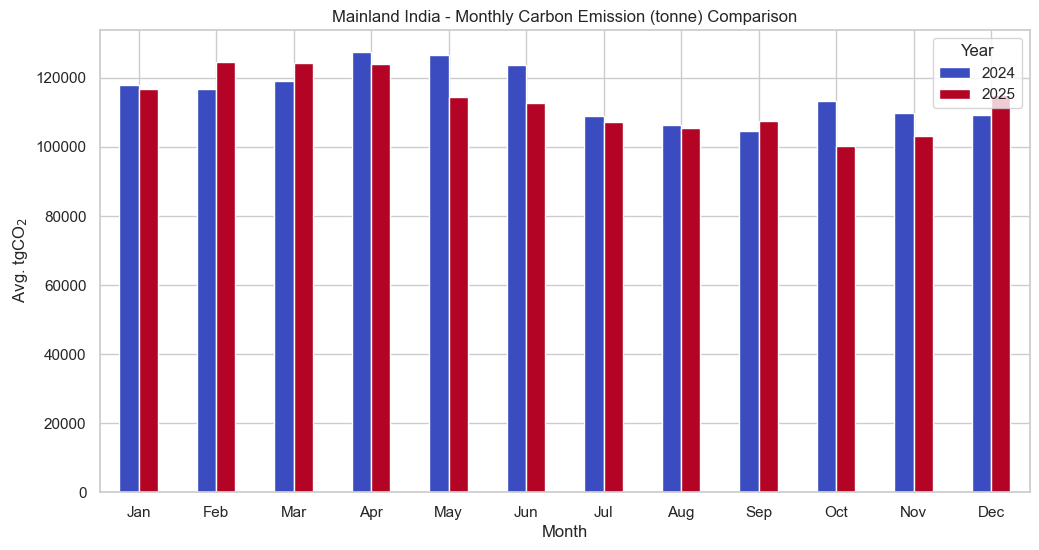

In [39]:

#  Monthly aggregation
monthly_emission = df.groupby(['Year', 'Month'])['Carbon Emission (tonne)'].mean().reset_index()

# Step 2: Pivot
comparison = monthly_emission.pivot(
    index='Month',
    columns='Year',
    values='Carbon Emission (tonne)'
)

# Step 3: Convert month numbers → names
comparison.index = comparison.index.map(lambda x: calendar.month_abbr[x])

# Step 4: Sort months properly
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

comparison = comparison.reindex(month_order)

# Step 5: Plot
comparison[[2024, 2025]].plot(
    kind='bar',
    figsize=(12,6),
    colormap='coolwarm'
)

plt.title("Mainland India - Monthly Carbon Emission (tonne) Comparison")
plt.xlabel("Month")
plt.ylabel(" Avg. tgCO$_2$ ")
plt.xticks(rotation=0)
plt.legend(title="Year")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

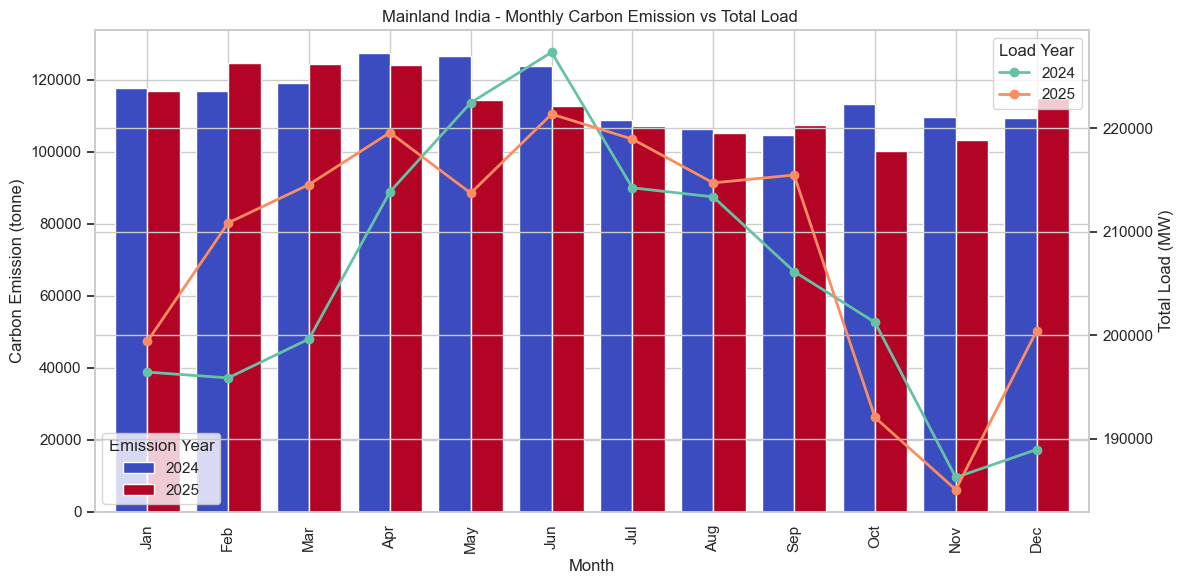

In [40]:
# Monthly Carbon Emissions vvs Total load

#  1: Monthly aggregation (BOTH features)
monthly_data = df.groupby(['Year', 'Month']).agg({
    'Carbon Emission (tonne)': 'mean',
    'Total Load MW': 'mean'
}).reset_index()

#  2: Pivot
emission = monthly_data.pivot(index='Month', columns='Year', values='Carbon Emission (tonne)')
load = monthly_data.pivot(index='Month', columns='Year', values='Total Load MW')

# : Month names
emission.index = emission.index.map(lambda x: calendar.month_abbr[x])
load.index = load.index.map(lambda x: calendar.month_abbr[x])

# Step 4: Correct order
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

emission = emission.reindex(month_order)
load = load.reindex(month_order)

# Step 5: Plot
fig, ax1 = plt.subplots(figsize=(12,6))

#  Bars  Emission
emission[[2024, 2025]].plot(
    kind='bar',
    ax=ax1,
    colormap='coolwarm',
    width=0.8
)

ax1.set_ylabel("Carbon Emission (tonne)")
ax1.ticklabel_format(style='plain', axis='y')

#  Line 
ax2 = ax1.twinx()

load[[2024, 2025]].plot(
    ax=ax2,
    marker='o',
    linewidth=2
)

ax2.set_ylabel("Total Load (MW)")

# Titles
ax1.set_title("Mainland India - Monthly Carbon Emission vs Total Load ")
ax1.set_xlabel("Month")

# Legends
ax1.legend(title="Emission Year", loc='lower left')
ax2.legend(title="Load Year", loc='best')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

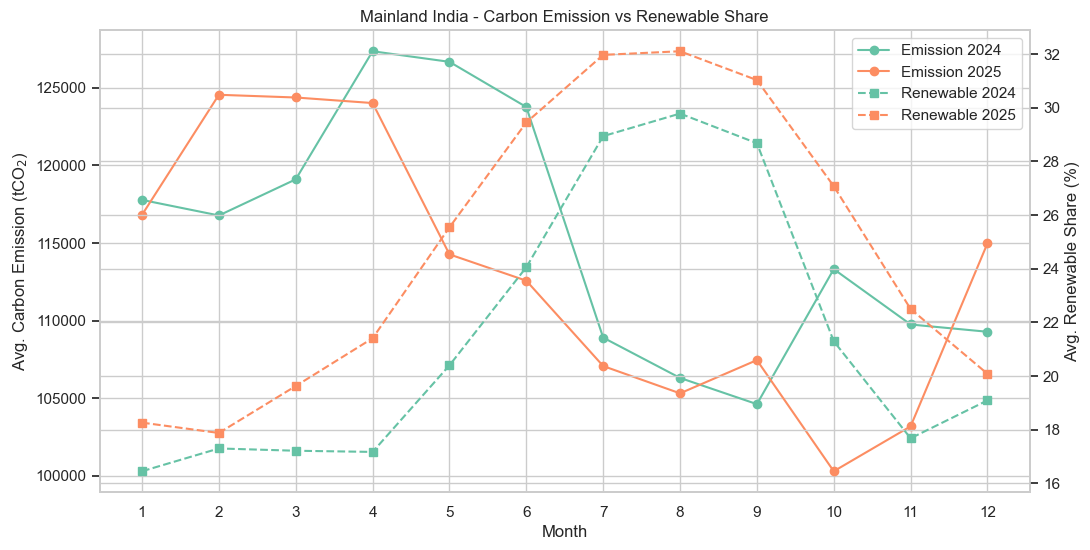

In [42]:

#  carbon Emission Vs renewable share 

monthly_mix = df.groupby(['Year','Month']).agg({
    'Carbon Emission (tonne)': 'mean',
    'Total Load MW': 'mean',
    'Renewable energy percentage (RE%)': 'mean'
}).reset_index()



fig, ax1 = plt.subplots(figsize=(12,6))

#  Carbon Emission
for year in [2024, 2025]:
    data = monthly_mix[monthly_mix['Year'] == year]
    
    ax1.plot(
        data['Month'],
        data['Carbon Emission (tonne)'],
        marker='o',
        label=f'Emission {year}'
    )

ax1.set_ylabel("Avg. Carbon Emission (tCO$_2$)")
ax1.set_xlabel("Month")

# Renewable Share
ax2 = ax1.twinx()

for year in [2024, 2025]:
    data = monthly_mix[monthly_mix['Year'] == year]
    
    ax2.plot(
        data['Month'],
        data['Renewable energy percentage (RE%)'],
        linestyle='--',
        marker='s',
        label=f'Renewable {year}'
    )

ax2.set_ylabel("Avg. Renewable Share (%)")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Mainland India - Carbon Emission vs Renewable Share")
plt.xticks(range(1, 13))
plt.show()





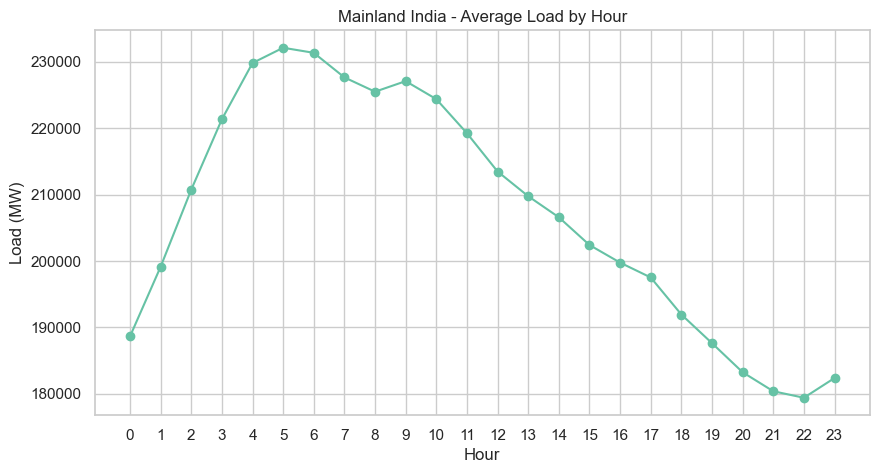

In [43]:

# Average Load by Hour


hourly_load = df.groupby('Hour')['Total Load MW'].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(hourly_load['Hour'], hourly_load['Total Load MW'], marker='o')

plt.title("Mainland India - Average Load by Hour")
plt.xlabel("Hour")
plt.ylabel("Load (MW)")
plt.xticks(range(0,24))

plt.show()

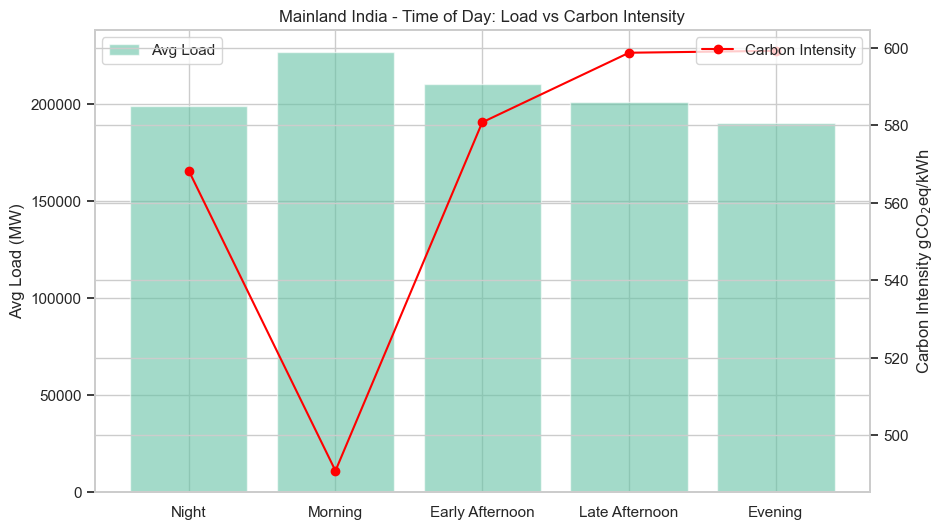

In [53]:
# Time od Day : Load vs Carbon Intensity

tod_data = df.groupby('TimeOfDay').agg({
    'Carbon intensity gCO2eq/kWh (direct)': 'mean',
    'Total Load MW': 'mean'
}).reindex(['Night','Morning','Early Afternoon','Late Afternoon','Evening'])

fig, ax1 = plt.subplots(figsize=(10,6))

#  Load (bar)
ax1.bar(
    tod_data.index,
    tod_data['Total Load MW'],
    alpha=0.6,
    label='Avg Load'
)

ax1.set_ylabel("Avg Load (MW)")

# Carbon Intensity (line)
ax2 = ax1.twinx()

ax2.plot(
    tod_data.index,
    tod_data['Carbon intensity gCO2eq/kWh (direct)'],
    color='red',
    marker='o',
    label='Carbon Intensity'
)

ax2.set_ylabel("Carbon Intensity gCO$_2$eq/kWh")

# Titles
plt.title("Mainland India - Time of Day: Load vs Carbon Intensity")

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

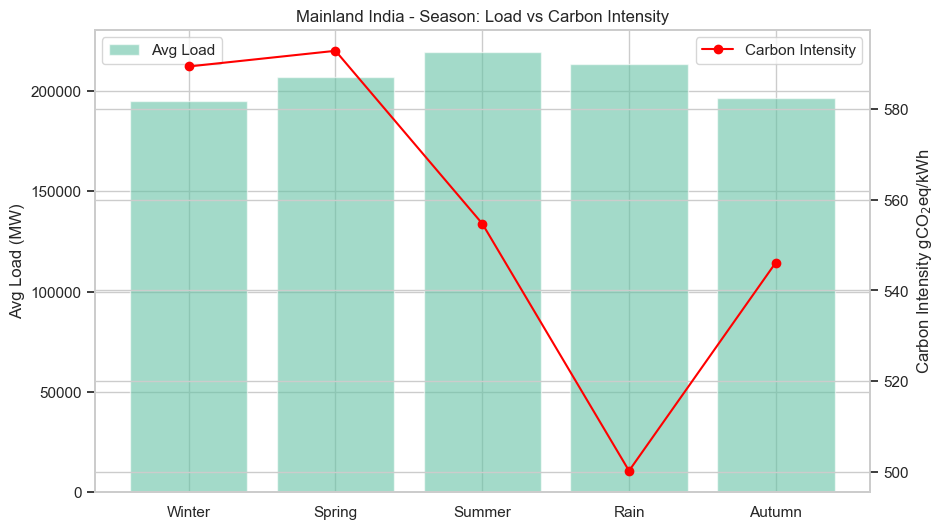

In [50]:
# Time od Day : Load vs Carbon Intensity

tod_data = df.groupby('Season').agg({
    'Carbon intensity gCO2eq/kWh (direct)': 'mean',
    'Total Load MW': 'mean'
}).reindex(['Winter','Spring','Summer','Rain','Autumn'])

fig, ax1 = plt.subplots(figsize=(10,6))

#  Load (bar)
ax1.bar(
    tod_data.index,
    tod_data['Total Load MW'],
    alpha=0.6,
    label='Avg Load'
)

ax1.set_ylabel("Avg Load (MW)")

# Carbon Intensity (line)
ax2 = ax1.twinx()

ax2.plot(
    tod_data.index,
    tod_data['Carbon intensity gCO2eq/kWh (direct)'],
    color='red',
    marker='o',
    label='Carbon Intensity'
)

ax2.set_ylabel("Carbon Intensity gCO$_2$eq/kWh")

# Titles
plt.title("Mainland India - Season: Load vs Carbon Intensity")

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

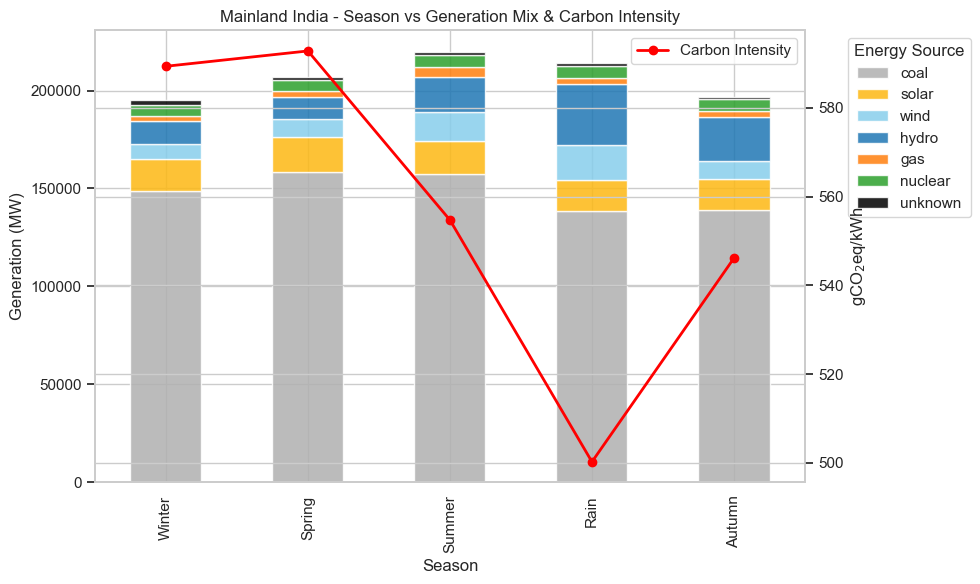

In [45]:
tod_data = df.groupby('Season').agg({
    'Carbon intensity gCO2eq/kWh (direct)': 'mean',
    'Total Load MW': 'mean',
    'coal': 'mean',
    'solar': 'mean',
    'wind': 'mean',
    'hydro': 'mean',
    'gas': 'mean',
    'nuclear': 'mean',
    'unknown' : 'mean'
}).reindex(['Winter','Spring','Summer','Rain','Autumn'])


# Select only generation columns
gen_cols = ['coal','solar','wind','hydro','gas','nuclear','unknown']


color_map = {
    'coal': '#b0b0b0',              
    'solar': '#FDB813',          
    'wind': '#87CEEB',           
    'hydro': '#1f77b4',          
    'gas': '#FF7F0E',            
    'nuclear': '#2ca02c', 
    'unknown' : 'black'
}

# Convert to ordered list
colors = [color_map[col] for col in gen_cols]

fig, ax1 = plt.subplots(figsize=(10,6))

# Stacked generation (USE colors instead of colormap)
tod_data[gen_cols].plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=colors,
    alpha=0.85
)

ax1.set_ylabel("Generation (MW)")

# Carbon intensity
ax2 = ax1.twinx()

ax2.plot(
    tod_data.index,
    tod_data['Carbon intensity gCO2eq/kWh (direct)'],
    color='red',   # better contrast than black
    marker='o',
    linewidth=2,
    label='Carbon Intensity'
)

ax2.set_ylabel("gCO$_2$eq/kWh")

plt.title("Mainland India - Season vs Generation Mix & Carbon Intensity")

# Legends (important fix)
ax1.legend(bbox_to_anchor=(1.05,1), title="Energy Source")
ax2.legend(loc='best')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



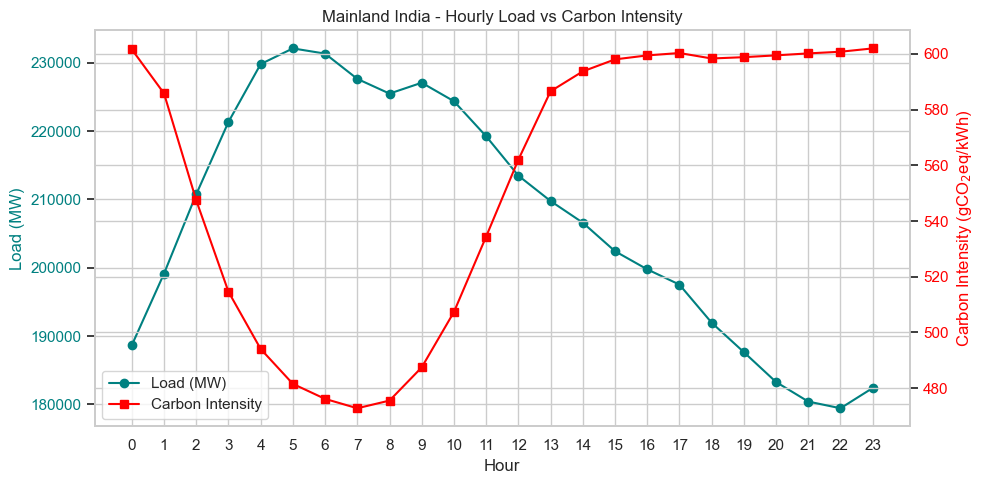

In [49]:
# Hourly Load Vs  Carbon Intensity

#  1: Aggregate both metrics
hourly_data = df.groupby('Hour').agg({
    'Total Load MW': 'mean',
    'Carbon intensity gCO2eq/kWh (direct)': 'mean'
}).reset_index()

#  2:  plot
fig, ax1 = plt.subplots(figsize=(10,5))

# Load 
ax1.plot(hourly_data['Hour'],
         hourly_data['Total Load MW'],
         color='teal',
         marker='o',
         label='Load (MW)')

ax1.set_xlabel("Hour")
ax1.set_ylabel("Load (MW)", color='teal')
ax1.tick_params(axis='y', labelcolor='teal')
ax1.set_xticks(range(0,24))

# Carbon Intensity 
ax2 = ax1.twinx()

ax2.plot(hourly_data['Hour'],
         hourly_data['Carbon intensity gCO2eq/kWh (direct)'],
         color='red',
         marker='s',
         label='Carbon Intensity')

ax2.set_ylabel("Carbon Intensity (gCO$_2$eq/kWh)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title("Mainland India - Hourly Load vs Carbon Intensity")

# Legends (combine both)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

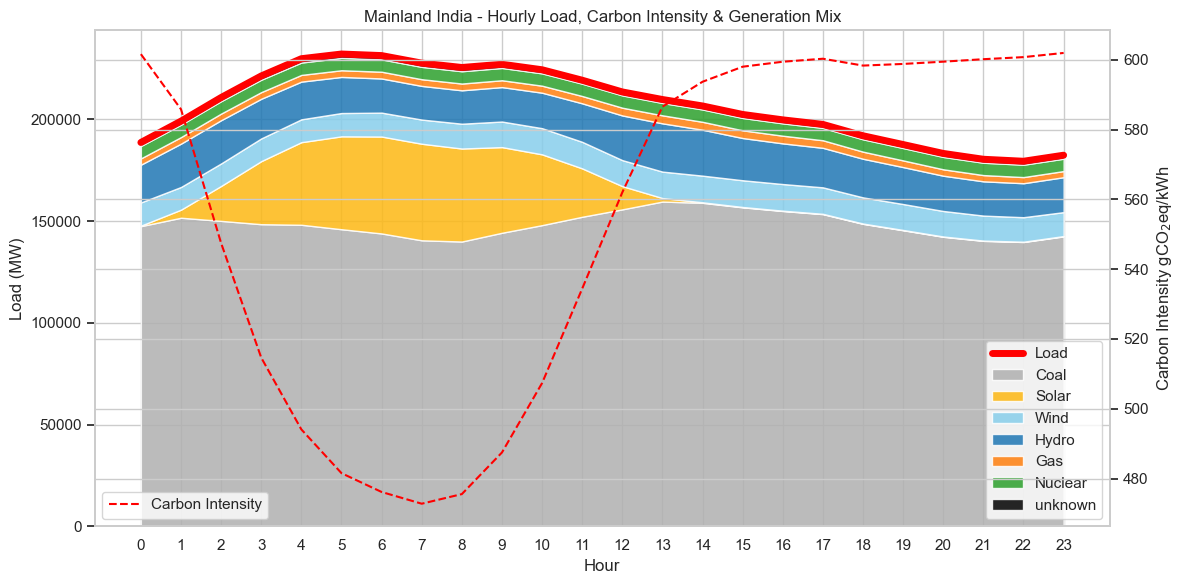

In [48]:

# Hourly load ,CArbon Intensity ,Generation Mix


hourly_data = df.groupby('Hour').agg({
    'Total Load MW': 'mean',
    'Carbon intensity gCO2eq/kWh (direct)': 'mean',
    'coal': 'mean',
    'solar': 'mean',
    'wind': 'mean',
    'hydro': 'mean',
    'gas': 'mean',
    'nuclear' : 'mean',
    'unknown' : 'mean'
}).reset_index()

color_map = {
    'coal': '#b0b0b0',              
    'solar': '#FDB813',          
    'wind': '#87CEEB',           
    'hydro': '#1f77b4',          
    'gas': '#FF7F0E',            
    'nuclear': '#2ca02c',
    'unknown': 'black'
}

fig, ax1 = plt.subplots(figsize=(12,6))

#  Load
ax1.plot(hourly_data['Hour'],
         hourly_data['Total Load MW'],
         color='red',
         linewidth=5,
         label='Load')

ax1.set_xlabel("Hour")
ax1.set_ylabel("Load (MW)")
ax1.set_xticks(range(0,24))

#  Carbon Intensity
ax2 = ax1.twinx()

ax2.plot(hourly_data['Hour'],
         hourly_data['Carbon intensity gCO2eq/kWh (direct)'],
         color='red',
         linestyle='--',
         label='Carbon Intensity')

ax2.set_ylabel("Carbon Intensity gCO$_2$eq/kWh")

#  Stacked Area (Generation Mix)
ax1.stackplot(
    hourly_data['Hour'],
    hourly_data['coal'],
    hourly_data['solar'],
    hourly_data['wind'],
    hourly_data['hydro'],
    hourly_data['gas'],
    hourly_data['nuclear'],
    hourly_data['unknown'],
    labels=['Coal','Solar','Wind','Hydro','Gas','Nuclear','unknown'],
    colors=[
        color_map['coal'],
        color_map['solar'],
        color_map['wind'],
        color_map['hydro'],
        color_map['gas'],
        color_map['nuclear'],
        color_map['unknown']
    ],
    alpha=0.85,
     edgecolor='white'
)

# Titles
plt.title("Mainland India - Hourly Load, Carbon Intensity & Generation Mix")

# Legends
ax1.legend(loc='lower right')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()



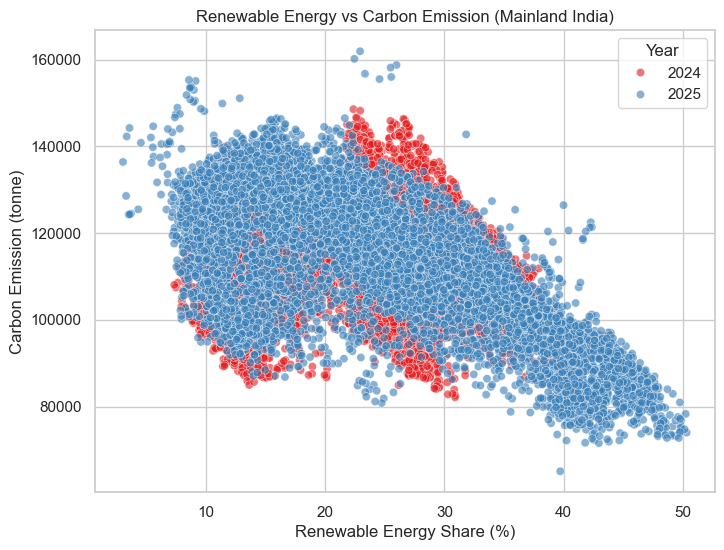

In [46]:

# Renewable Energy vs Carbon Emission
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Renewable energy percentage (RE%)',
    y='Carbon Emission (tonne)',
    hue='Year',
    palette='Set1',   
    alpha=0.6
)



plt.title("Renewable Energy vs Carbon Emission (Mainland India)")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Carbon Emission (tonne)")
plt.legend(title="Year")
plt.show()

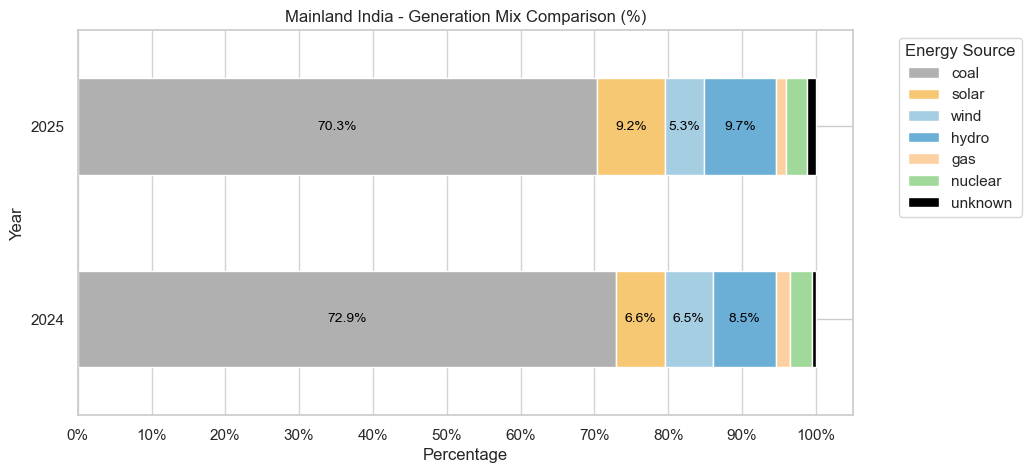

In [47]:
# Generation Mix Comparison

gen_cols = ['coal','solar','wind','hydro','gas','nuclear','unknown']
color_map = {
    'coal': '#b0b0b0',      # dark grey (not black)
    'solar': '#f7c873',
    'wind': '#a6cee3',
    'hydro': '#6baed6',
    'gas': '#fdd0a2',
    'nuclear': '#a1d99b',
    'unknown': 'black'
}

gen_year = df.groupby('Year')[gen_cols].sum()

# Convert to percentage
gen_pct = gen_year.div(gen_year.sum(axis=1), axis=0) * 100

ax = gen_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(10,5),
    color=[color_map[col] for col in gen_cols]
)

plt.title("Mainland India - Generation Mix Comparison (%)")
plt.xlabel("Percentage")
plt.ylabel("Year")

# Axis formatting
ax.xaxis.set_major_locator(mtick.MultipleLocator(10))
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

#  Add small % labels inside bars
for i, year in enumerate(gen_pct.index):
    cumulative = 0
    
    for col in gen_cols:
        value = gen_pct.loc[year, col]
        
       
        if value > 3:   
            ax.text(
                cumulative + value/2,
                i,
                f"{value:.1f}%",
                ha='center',
                va='center',
                fontsize=10,     
                color='black'
            )
        
        cumulative += value

plt.legend(bbox_to_anchor=(1.05, 1), title="Energy Source")
plt.grid(axis='x', linestyle='solid', alpha=0.85)

plt.show()

In [28]:
df.to_csv("pre-processed_data.csv", index=False)